# Lista de Exercícios: Análise Exploratória de Dados com Pandas

Para praticar os conceitos (inspeção inicial, valores ausentes, máscaras booleanas, filtragem com .loc e agrupamentos com groupby), utilizaremos um dataset público obtido no Kaggle.

&nbsp;

## Dataset

[Pakistan largest e-commerce dataset](https://www.kaggle.com/datasets/zusmani/pakistans-largest-ecommerce-dataset)


In [1]:
#alteração simples
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Bloco 1: Primeiras Inspeções e Limpeza de Estrutura
**Objetivo:** Carregar os dados, identificar imperfeições de importação e entender os tipos primitivos.

1. Carregue o arquivo CSV utilizando o Pandas e armazene-o em uma variável chamada `df_pakistan`.

In [2]:
df_pakistan = pd.read_csv(r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\5 - ANÁLISE EXPLORATÓRIA DE DADOS - DE 28-05-2026 A 02-07-2026\2026 05 28\AULA CORRIGIDA\Pakistan.csv")

C:\Users\User\AppData\Local\Temp\ipykernel_6440\4018848995.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pakistan = pd.read_csv(r"C:\Users\User\Desktop\BECKUP - PALMEIRAS\CAIXAVERSO - ADA\AULAS PRESENCIAIS\5 - ANÁLISE EXPLORATÓRIA DE DADOS - DE 28-05-2026 A 02-07-2026\2026 05 28\AULA CORRIGIDA\Pakistan.csv")


2. Exiba as 7 primeiras linhas do DataFrame. Observe se existem colunas irrelevantes criadas por artefatos do arquivo original (como colunas que começam com `Unnamed:`).


In [3]:
df_pakistan.head(7)

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN
5,211137.0,canceled,7/1/2016,UK_Namkino All In One 200 Gms,80.0,1.0,80.0,100147448,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,6.0,NaN,NaN,NaN,NaN,NaN
6,211138.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147449,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,7.0,NaN,NaN,NaN,NaN,NaN


3. Verifique a dimensão original do DataFrame (`.shape`). Explique por que o número total de linhas parece desalinhado com o volume real de transações do e-commerce (dica: verifique a presença de linhas inteiramente nulas ao final do arquivo).


In [4]:
df_pakistan.shape

(1048575, 26)

4. Execute o método `.info()`. Quais colunas foram detectadas como numéricas (`float64`, `int64`) e quais são textuais (`object`)? Identifique se colunas estruturais como `item_id` ou `Customer ID` receberam tipos numéricos inadequados devido à presença de valores nulos.

In [5]:
df_pakistan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

## Bloco 2: Diagnóstico e Tratamento de Valores Ausentes
**Objetivo:** Isolar e tratar dados nulos ou ruidosos gerados pela importação.

5. Calcule a quantidade exata de valores ausentes (`NaN`) em cada uma das colunas do DataFrame.

In [6]:
df_pakistan.isnull().sum()

item_id                   464051
status                    464066
created_at                464051
sku                       464071
price                     464051
qty_ordered               464051
grand_total               464051
increment_id              464051
category_name_1           464215
sales_commission_code     601229
discount_amount           464051
payment_method            464051
Working Date              464051
BI Status                 464051
 MV                       464051
Year                      464051
Month                     464051
Customer Since            464062
M-Y                       464051
FY                        464051
Customer ID               464062
Unnamed: 21              1048575
Unnamed: 22              1048575
Unnamed: 23              1048575
Unnamed: 24              1048575
Unnamed: 25              1048575
dtype: int64

6. Elimine as colunas fantasmas que vão de `Unnamed: 21` até `Unnamed: 25` utilizando o método `.drop()` ou seleção de colunas. Em seguida, utilize o método `.dropna(how='all')` para descartar linhas que estejam completamente vazias. Verifique o novo `.shape` do DataFrame.

In [8]:
# Excluir colunas pelo nome
df_pakistan = df_pakistan.drop(columns=["Unnamed: 21","Unnamed: 22","Unnamed: 23","Unnamed: 24","Unnamed: 25"], errors="ignore")
# Excluir linhas onde item_id está vazio (NaN)
df_pakistan = df_pakistan[~df_pakistan["item_id"].isna()]

In [9]:
df_pakistan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584524 entries, 0 to 584523
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-null  o

In [10]:
df_pakistan.isnull().sum()

item_id                       0
status                       15
created_at                    0
sku                          20
price                         0
qty_ordered                   0
grand_total                   0
increment_id                  0
category_name_1             164
sales_commission_code    137178
discount_amount               0
payment_method                0
Working Date                  0
BI Status                     0
 MV                           0
Year                          0
Month                         0
Customer Since               11
M-Y                           0
FY                            0
Customer ID                  11
dtype: int64

7. A coluna `status` possui uma pequena fração de valores nulos. Crie uma máscara booleana para isolar e exibir as linhas onde o status do pedido está ausente. Substitua esses valores nulos pelo termo `"unknown"` utilizando o seletor `.loc`.

In [11]:
df_pakistan[df_pakistan["status"].isna()]

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
477519,783751.0,NaN,3/15/2018,OTHPCB5A7D8A0BD10E8,8000.0,1.0,8000.0,100479380,Others,NaN,...,cod,3/15/2018,Gross,"8,000",2018.0,3.0,2018-3,3-2018,FY18,95141.0
513736,827187.0,NaN,4/16/2018,KABOXF5ABCC75C7E2F7-32,370.0,1.0,2707.0,100513933,Kids & Baby,NaN,...,cod,4/16/2018,Gross,370,2018.0,4.0,2018-4,4-2018,FY18,105059.0
513737,827189.0,NaN,4/16/2018,KABSHO5AA77C331466F-11-13 Years,473.0,1.0,2707.0,100513933,Kids & Baby,NaN,...,cod,4/16/2018,Gross,473,2018.0,4.0,2018-4,4-2018,FY18,105059.0
513738,827191.0,NaN,4/16/2018,KABBIN5A93E074C501A-8-9 Years,749.0,1.0,2707.0,100513933,Kids & Baby,NaN,...,cod,4/16/2018,Gross,749,2018.0,4.0,2018-4,4-2018,FY18,105059.0
513739,827193.0,NaN,4/16/2018,KABLIT59AC117FD51C4-12-13 Years,692.0,1.0,2707.0,100513933,Kids & Baby,NaN,...,cod,4/16/2018,Gross,692,2018.0,4.0,2018-4,4-2018,FY18,105059.0
513740,827195.0,NaN,4/16/2018,KABCOL5AB2B8019805C-8-9 Years,423.0,1.0,2707.0,100513933,Kids & Baby,NaN,...,cod,4/16/2018,Gross,423,2018.0,4.0,2018-4,4-2018,FY18,105059.0
518706,832777.0,NaN,4/30/2018,ENTCLI5A5DD7D800D6E,6042.0,1.0,6042.0,100517141,Entertainment,NaN,...,cod,4/30/2018,Gross,"6,042",2018.0,4.0,2018-4,4-2018,FY18,106036.0
532965,848003.0,NaN,5/14/2018,MATINF5AE310D2D7A1A,13950.0,1.0,13950.0,100527966,Mobiles & Tablets,NaN,...,cod,5/14/2018,Gross,"13,950",2018.0,5.0,2018-4,5-2018,FY18,105319.0
542146,857829.0,NaN,5/25/2018,ROO5AE983F2751EA,2280.0,1.0,2280.0,100534786,Superstore,NaN,...,cod,5/25/2018,Gross,"2,280",2018.0,5.0,2018-5,5-2018,FY18,109580.0
554962,872154.0,NaN,6/15/2018,BAGPHI5AA665985A58E,2900.0,1.0,949.0,100542483,Beauty & Grooming,NaN,...,bankalfalah,6/15/2018,Gross,"2,900",2018.0,6.0,2018-5,6-2018,FY18,109420.0


In [49]:
mascara = df_pakistan["status"].isna()
df_pakistan.loc[mascara, "status"] = "unknown"
df_pakistan.isnull().sum()

item_id                       0
status                        0
created_at                    0
sku                          20
price                         0
qty_ordered                   0
grand_total                   0
increment_id                  0
category_name_1             164
sales_commission_code    137178
discount_amount               0
payment_method                0
Working Date                  0
BI Status                     0
 MV                           0
Year                          0
Month                         0
Customer Since               11
M-Y                           0
FY                            0
Customer ID                  11
dtype: int64

## Bloco 3: Máscaras Booleanas e Filtragem Avançada
**Objetivo:** Executar filtros condicionais complexos combinando variáveis textuais e numéricas.

8. Crie uma máscara booleana para filtrar apenas as transações onde a categoria do produto (`category_name_1`) seja `"Mobiles & Tablets"`. Exiba as primeiras 5 linhas resultantes.

In [12]:
mob_tab = df_pakistan.loc[df_pakistan["category_name_1"] == "Mobiles & Tablets"]
mob_tab.shape

(115710, 21)

In [13]:
mob_tab.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
8,211140.0,canceled,7/1/2016,Apple iPhone 6S 64GB,96499.0,1.0,96499.0,100147451,Mobiles & Tablets,\N,...,ublcreditcard,7/1/2016,Gross,"96,499",2016.0,7.0,2016-7,7-2016,FY17,8.0
9,211141.0,canceled,7/1/2016,Apple iPhone 6S 64GB,96499.0,1.0,96499.0,100147452,Mobiles & Tablets,\N,...,mygateway,7/1/2016,Gross,"96,499",2016.0,7.0,2016-7,7-2016,FY17,8.0
31,211168.0,complete,7/1/2016,Samsung Galaxy J5,20999.0,1.0,20999.0,100147466,Mobiles & Tablets,R-FSD-58130,...,cod,7/1/2016,Net,"20,999",2016.0,7.0,2016-7,7-2016,FY17,20.0
42,211180.0,canceled,7/1/2016,Lexon_LL116B-Blue,3600.0,1.0,11000.0,100147473,Mobiles & Tablets,\N,...,mygateway,7/1/2016,Gross,"3,600",2016.0,7.0,2016-7,7-2016,FY17,25.0
45,211185.0,complete,7/1/2016,Q MOBILE Noir X20,4500.0,1.0,4500.0,100147475,Mobiles & Tablets,\N,...,cod,7/1/2016,Net,"4,500",2016.0,7.0,2016-7,7-2016,FY17,26.0


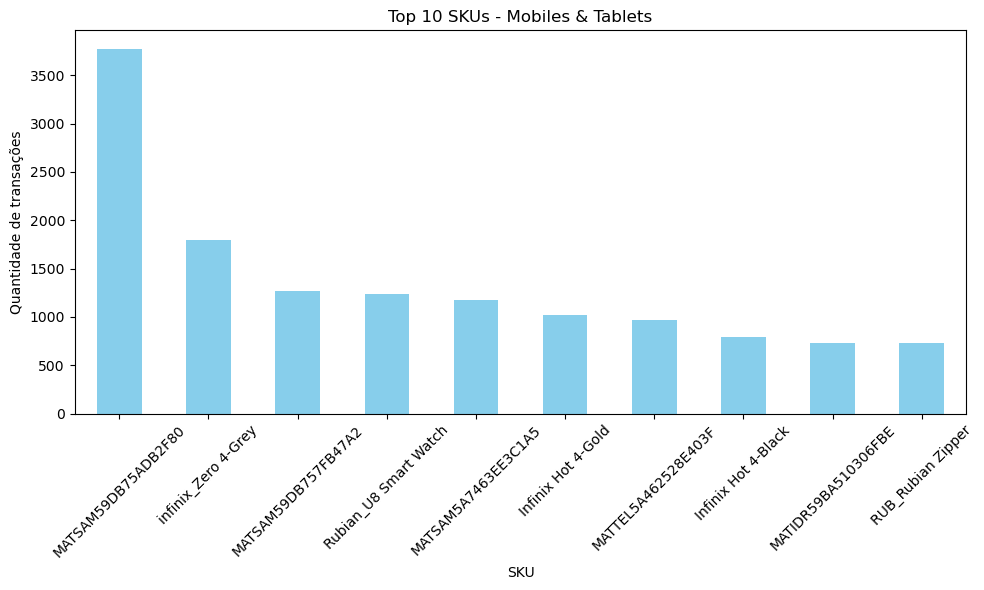

In [14]:
sku_counts = mob_tab["sku"].value_counts().head(10)
# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sku_counts.plot(kind="bar", color="skyblue")
plt.title("Top 10 SKUs - Mobiles & Tablets")
plt.xlabel("SKU")
plt.ylabel("Quantidade de transações")
plt.xticks(rotation=45)
plt.tight_layout()  # ajusta layout para não cortar rótulos
plt.show()

9. Utilizando os operadores lógicos (`&`, `|`), filtre as transações que possuem status igual a `"complete"` **E** quantidade de itens ordenados (`qty_ordered`) estritamente maior que 5. Certifique-se de delimitar os critérios com parênteses.

In [53]:
# Filtrar transações com status "complete" E quantidade de itens > 5
filtro = (df_pakistan["status"] == "complete") & (df_pakistan["qty_ordered"] > 5)
transacoes_filtradas = df_pakistan.loc[filtro]
# Ordenar por quantidade de itens (decrescente)
transacoes_filtradas = transacoes_filtradas.sort_values(by="qty_ordered", ascending=False)
transacoes_filtradas.shape

(809, 21)

In [54]:
transacoes_filtradas.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
240079,"508,369.00",complete,6/9/2017,IDROID_BALRX7-Jet black,"8,944.00","1,000.00","17,888,000.00",100323649,Mobiles & Tablets,\N,...,jazzvoucher,6/9/2017,Net,"8,944,000","2,017.00",6.00,2017-6,6-2017,FY17,"50,387.00"
240078,"508,368.00",complete,6/9/2017,IDROID_BALRX7-Gold,"8,944.00","1,000.00","17,888,000.00",100323649,Mobiles & Tablets,\N,...,jazzvoucher,6/9/2017,Net,"8,944,000","2,017.00",6.00,2017-6,6-2017,FY17,"50,387.00"
417155,"715,228.00",complete,12/13/2017,BAGLUX5A099F4DDC6A7,150.00,200.00,"30,000.00",100436773,Beauty & Grooming,\N,...,cod,12/13/2017,Net,"30,000","2,017.00",12.00,2017-12,12-2017,FY18,"83,140.00"
417157,"715,230.00",complete,12/13/2017,BAGLUX5A099F4DDC6A7,150.00,200.00,"30,000.00",100436775,Beauty & Grooming,\N,...,cod,12/13/2017,Net,"30,000","2,017.00",12.00,2017-12,12-2017,FY18,"83,140.00"
201053,"462,932.00",complete,5/3/2017,Jayqeu_BL-01-Red-S,300.00,150.00,"150,000.00",100300416,Women's Fashion,R-KHW-50744,...,cashatdoorstep,5/3/2017,Net,"45,000","2,017.00",5.00,2016-7,5-2017,FY17,802.00


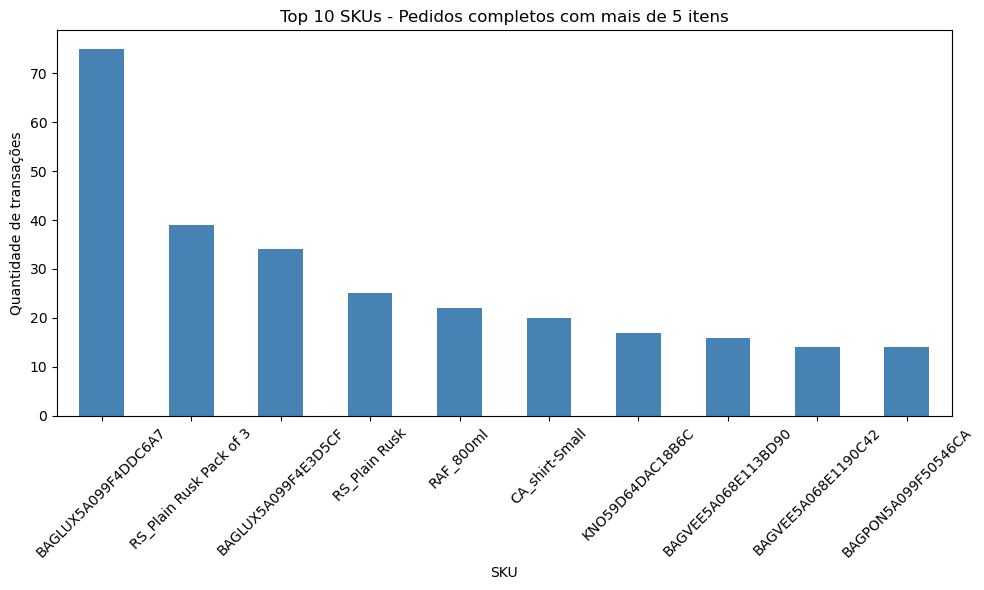

In [55]:
# Contar frequência de cada SKU e pegar os 10 mais comuns
sku_counts = transacoes_filtradas["sku"].value_counts().head(10)
# Plotar gráfico de barras
plt.figure(figsize=(10,6))
sku_counts.plot(kind="bar", color="steelblue")
plt.title("Top 10 SKUs - Pedidos completos com mais de 5 itens")
plt.xlabel("SKU")
plt.ylabel("Quantidade de transações")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

10. Utilizando o método `.loc`, selecione todas as transações cujo método de pagamento (`payment_method`) seja `"cod"` (Cash on Delivery) e recupere apenas as colunas `sku`, `price` e `grand_total`.

In [61]:
# Selecionar transações com pagamento "cod" e mostrar apenas sku, price e grand_total
cod_transacoes = df_pakistan.loc[df_pakistan["payment_method"] == "cod", ["payment_method","sku", "price", "grand_total"]]
cod_trans = df_pakistan.loc[df_pakistan["payment_method"] == "cod", ["sku", "price", "grand_total"]]
cod_transacoes.shape

(271960, 4)

In [62]:
cod_transacoes.head()

,payment_method,sku,price,grand_total
0,cod,kreations_YI 06-L,"1,950.00","1,950.00"
1,cod,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.00,240.00
2,cod,Ego_UP0017-999-MR0,"2,450.00","2,450.00"
3,cod,kcc_krone deal,360.00,60.00
4,cod,BK7010400AG,555.00,"1,110.00"


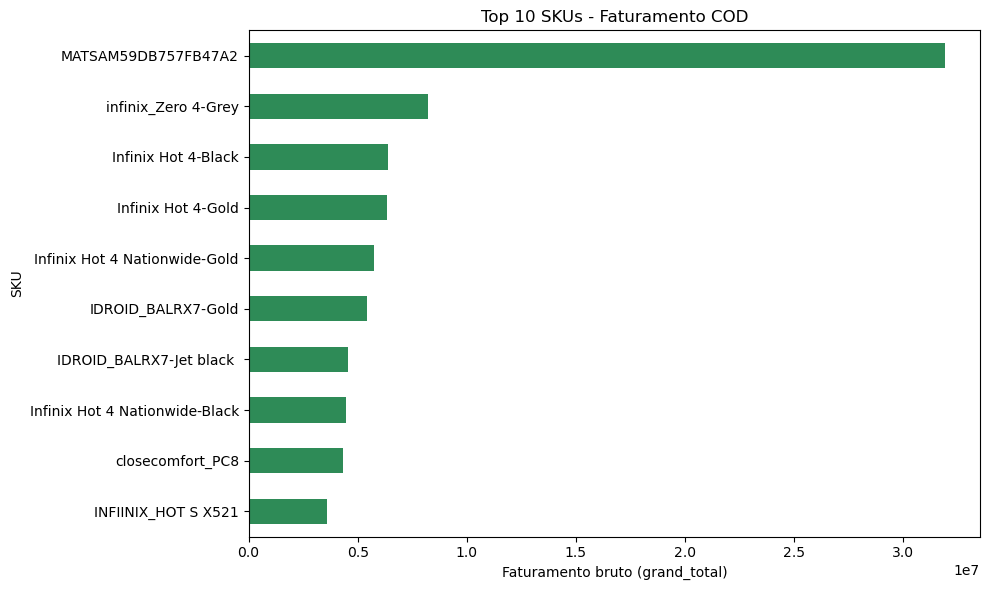

In [63]:
# Agrupar por SKU e somar o faturamento bruto
sku_faturamento = cod_trans.groupby("sku")["grand_total"].sum().sort_values(ascending=False).head(10)
# Plotar gráfico de barras horizontais
plt.figure(figsize=(10,6))
sku_faturamento.plot(kind="barh", color="seagreen")
plt.title("Top 10 SKUs - Faturamento COD")
plt.xlabel("Faturamento bruto (grand_total)")
plt.ylabel("SKU")
plt.gca().invert_yaxis()  # maior valor no topo
plt.tight_layout()
plt.show()

## Bloco 4: Agrupamentos e Insights de Negócio

**Objetivo:** Consolidar métricas financeiras e volumétricas por categorias operacionais.

11. Determine quais são os métodos de pagamento mais comuns no e-commerce paquistanês aplicando o método `.value_counts()` na coluna `payment_method`.

In [64]:
# Contar frequência dos métodos de pagamento
metodos_pag = df_pakistan["payment_method"].value_counts()
metodos_pagamento = df_pakistan["payment_method"].value_counts().reset_index()
metodos_pagamento.columns = ["payment_method", "quantidade"]
# Criar coluna com somatório cumulativo (linha atual + anteriores)
metodos_pagamento["soma_cumulativa"] = metodos_pagamento["quantidade"].cumsum()
metodos_pagamento

,payment_method,quantidade,soma_cumulativa
0,cod,271960,271960
1,Payaxis,97641,369601
2,Easypay,82900,452501
3,jazzwallet,35145,487646
4,easypay_voucher,31176,518822
5,bankalfalah,23065,541887
6,jazzvoucher,15633,557520
7,Easypay_MA,14028,571548
8,customercredit,7555,579103
9,apg,1758,580861


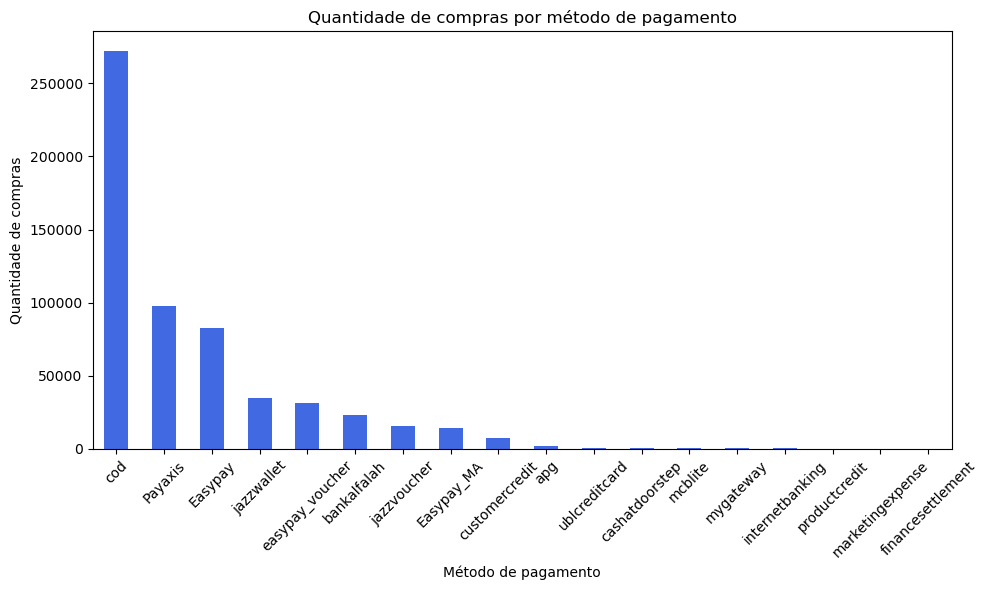

In [33]:
# Plotar gráfico de barras
plt.figure(figsize=(10,6))
metodos_pag.plot(kind="bar", color="royalblue")
plt.title("Quantidade de compras por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Quantidade de compras")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

12. Utilizando o método `.groupby()`, calcule o faturamento bruto acumulado (`grand_total`) para cada categoria de produto (`category_name_1`).

In [34]:
pd.options.display.float_format = "{:,.2f}".format
# Agrupar por categoria e somar o faturamento bruto
faturamento_por_categoria = (df_pakistan.groupby("category_name_1")["grand_total"].sum().reset_index().sort_values(by="grand_total", ascending=False))
print(faturamento_por_categoria)

       category_name_1      grand_total
9    Mobiles & Tablets 2,440,790,684.02
0           Appliances   656,849,685.76
4        Entertainment   539,047,961.03
14     Women's Fashion   282,577,916.46
3            Computing   202,545,691.74
8        Men's Fashion   194,139,018.70
10              Others   192,465,576.51
13          Superstore   112,130,876.72
1    Beauty & Grooming    97,185,738.76
6        Home & Living    88,217,075.82
7          Kids & Baby    47,237,430.67
12             Soghaat    46,343,248.42
5      Health & Sports    41,794,746.08
15                  \N    35,829,386.73
11  School & Education     6,237,084.13
2                Books     2,676,194.69


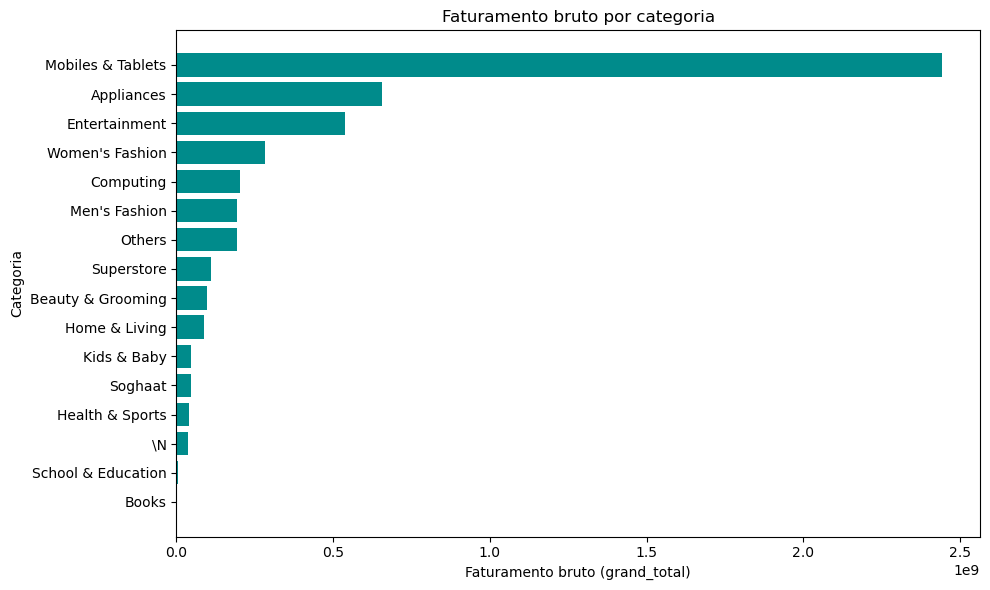

In [65]:
# Plotar gráfico de barras horizontais
plt.figure(figsize=(10,6))
plt.barh(faturamento_por_categoria["category_name_1"], faturamento_por_categoria["grand_total"], color="darkcyan")
plt.title("Faturamento bruto por categoria")
plt.xlabel("Faturamento bruto (grand_total)")
plt.ylabel("Categoria")
plt.gca().invert_yaxis()  # maior valor no topo
plt.tight_layout()
plt.show()





13. **Desafio de Negócio:** Agrupe os dados por `status` do pedido e calcule simultaneamente a quantidade total de itens vendidos (`qty_ordered`) e a receita média (`grand_total`). Ordene o resultado final com base na quantidade total de itens de forma decrescente para identificar o impacto financeiro de pedidos cancelados ou reembolsados.

In [66]:
# Agrupar por status e calcular métricas
impacto_status = (df_pakistan.groupby("status").agg(total_itens=("qty_ordered", "sum"),receita_media=("grand_total", "mean")).reset_index().sort_values(by="total_itens", ascending=False))
impacto_status

,status,total_itens,receita_media
4,complete,"278,990.00","5,014.34"
1,canceled,"278,570.00","14,437.37"
14,received,"110,284.00","5,635.42"
8,order_refunded,"74,328.00","6,936.70"
15,refund,"9,614.00","3,764.51"
3,cod,"3,366.00","4,328.16"
9,paid,"1,722.00","7,602.03"
2,closed,538.00,"7,284.45"
10,payment_review,168.00,"4,116.66"
11,pending,70.00,"26,119.05"


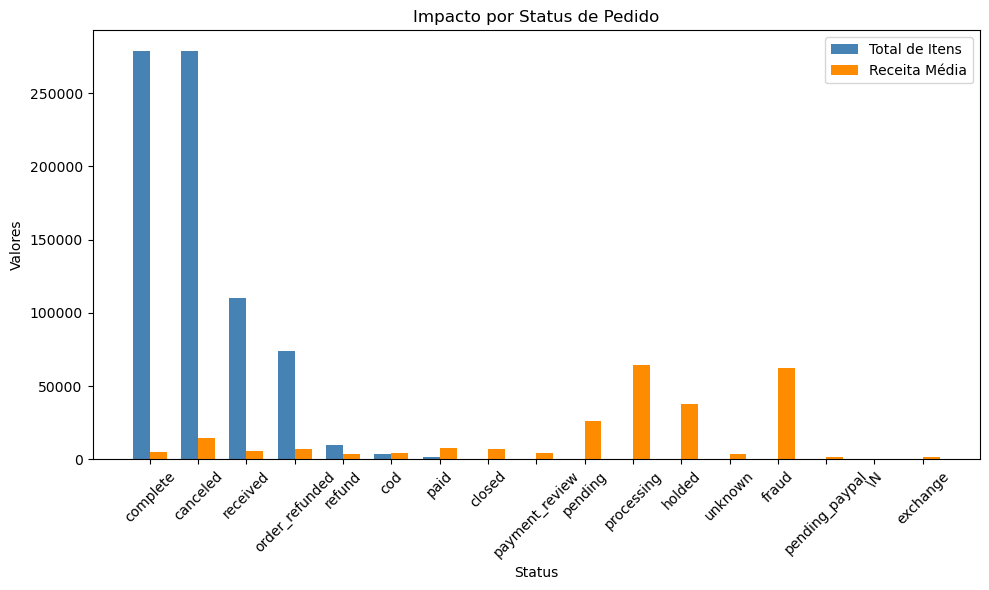

In [67]:
# Configurar posições
x = np.arange(len(impacto_status["status"]))
largura = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - largura/2, impacto_status["total_itens"], largura, label="Total de Itens", color="steelblue")
plt.bar(x + largura/2, impacto_status["receita_media"], largura, label="Receita Média", color="darkorange")
plt.title("Impacto por Status de Pedido")
plt.xlabel("Status")
plt.ylabel("Valores")
plt.xticks(x, impacto_status["status"], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()